### Load model and freeze/unfreeze parameters.

In [2]:
# load dependencies
import numpy as np
import torch
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import tqdm
from sklearn.metrics import confusion_matrix, classification_report

# enable gpu access
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# load 'alexnet' with pretrained weights
model = models.alexnet(weights = models.AlexNet_Weights.IMAGENET1K_V1)

# output layer nodes 1000 --> 1
model.classifier[6] = nn.Linear(in_features = 4096, out_features = 1)

In [5]:
# freeze all params
for param in model.parameters():
    param.requires_grad = False

# freeze conv1, conv2 --> unfreeze conv3, conv4, conv5
layer_idx = [6, 8, 10]
for idx in layer_idx:
    for param in model.features[idx].parameters():
        param.requires_grad = True

# unfreeze classifier head
for param in model.classifier.parameters():
    param.requires_grad = True

### Set up train/val datasets and dataloaders

In [6]:
# train/val augmentations
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale = (0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

In [7]:
# train/val datasets
train_dataset = ImageFolder(
    root = 'dataset/train',
    transform = train_transforms
)

val_dataset = ImageFolder(
    root = 'dataset/val',
    transform = val_transforms
)

test_dataset = ImageFolder(
    root = 'dataset/test',
    transform = val_transforms
)

print(train_dataset.class_to_idx)

{'bad_quality': 0, 'good_quality': 1}


In [15]:
# train/val dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False,
    num_workers = 4,
    pin_memory = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False,
    num_workers = 4,
    pin_memory = True
)

### Set up differential learning rates, optimizer, scheduler and criterion

In [16]:
# discriminative learning rates 
fc_params = list(model.classifier.parameters())
conv_345_params = (
    list(model.features[6].parameters()) +
    list(model.features[8].parameters()) + 
    list(model.features[10].parameters())
)

# optimizer with discriminative learning rates + weight decay
optimizer = torch.optim.AdamW(
    [
        {'params': fc_params, 'lr': 1e-4},
        {'params': conv_345_params, 'lr': 1e-5}
    ],
    weight_decay = 1e-4
)

# criterion is BCEWithLogitsLoss
criterion = torch.nn.BCEWithLogitsLoss()

# lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.1
)

# move model to device
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
# training params 
epochs = 5
patience = 3
best_val_loss = np.inf
no_improve = 0
scaler = torch.amp.GradScaler('cuda')
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

# training loop
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    for imgs, labels in tqdm.tqdm(train_loader, desc = f'train epoch {epoch + 1}/{epochs}'):
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad(set_to_none = True)
        
        with torch.amp.autocast(device_type = 'cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * imgs.size(0)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        train_correct += (preds == labels).sum().item()
    
    train_loss /= len(train_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)

    # validation loop
    model.eval()
    val_loss = 0.0
    val_correct = 0
    with torch.no_grad():
        for imgs, labels in tqdm.tqdm(val_loader, desc = 'valid'):
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            with torch.amp.autocast(device_type = 'cuda'):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            val_correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        scheduler.step(val_loss) 

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")  

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'best_val_loss': best_val_loss
            }
            torch.save(checkpoint, f'val_acc_{val_acc}_model.pth')
            print('Saved model checkpoint')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping triggered at epoch: {epoch}')
                break
# frozen model specs - training acc: 0.996, val_acc: 0.997

valid: 100%|██████████| 13/13 [00:09<00:00,  1.34it/s]



Epoch 1/5
Train Loss: 0.1697 | Train Acc: 0.9263
Val   Loss: 0.0281 | Val   Acc: 0.9880
Saved model checkpoint


valid: 100%|██████████| 13/13 [00:08<00:00,  1.50it/s]



Epoch 2/5
Train Loss: 0.0305 | Train Acc: 0.9855
Val   Loss: 0.0145 | Val   Acc: 0.9928
Saved model checkpoint


valid: 100%|██████████| 13/13 [00:08<00:00,  1.48it/s]



Epoch 3/5
Train Loss: 0.0237 | Train Acc: 0.9890
Val   Loss: 0.0259 | Val   Acc: 0.9904


valid: 100%|██████████| 13/13 [00:08<00:00,  1.53it/s]



Epoch 4/5
Train Loss: 0.0198 | Train Acc: 0.9924
Val   Loss: 0.0063 | Val   Acc: 0.9976
Saved model checkpoint


valid: 100%|██████████| 13/13 [00:08<00:00,  1.50it/s]



Epoch 5/5
Train Loss: 0.0121 | Train Acc: 0.9966
Val   Loss: 0.0051 | Val   Acc: 0.9976
Saved model checkpoint


In [31]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            outputs = model(imgs)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long()

        # Move to CPU and flatten
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

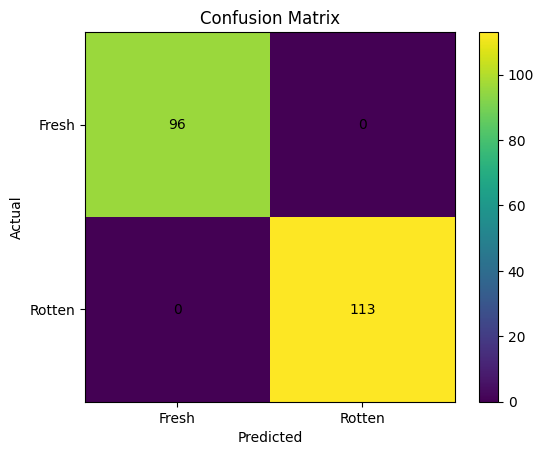

In [35]:
cm = confusion_matrix(all_preds, all_labels)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Fresh", "Rotten"])
plt.yticks([0, 1], ["Fresh", "Rotten"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


In [37]:
# classification report
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Fresh", "Rotten"]
))

              precision    recall  f1-score   support

       Fresh       1.00      1.00      1.00        96
      Rotten       1.00      1.00      1.00       113

    accuracy                           1.00       209
   macro avg       1.00      1.00      1.00       209
weighted avg       1.00      1.00      1.00       209

